# 06 SHAP Explainability

SHAP (SHapley Additive exPlanations) answers the question the confusion matrix can't:  
**why** is a specific customer predicted to churn?

This notebook produces four artifacts:
1. **Summary plot**: global feature importance across all customers  
2. **Beeswarm plot**: direction and magnitude of each feature's effect  
3. **Dependence plots**: how the top features interact with churn probability  
4. **Individual explanation**: a waterfall chart for a single at-risk customer

All plots are saved to `Reports/` for the portfolio README.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

shap.initjs()
print("Libraries loaded.")

Libraries loaded.


In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../Data/processed/feature_engineered_data.csv")

X = df.drop("Churned", axis=1)
y = df["Churned"]

# Drop City — too granular, mostly noise
X = X.drop("City", axis=1)

# One-hot encode remaining categoricals
X = pd.get_dummies(X, drop_first=True)

# Train/test split — must match exactly what model was trained on
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {X.shape[1]}")
print(f"Test set: {X_test.shape[0]:,} rows")

Features: 37
Test set: 10,000 rows


In [4]:
# Load model and feature list
xgb_model = joblib.load("../Models/xgb_churn_model.pkl")
feature_cols = joblib.load("../Models/model_features.pkl")

print(f"Model loaded: {xgb_model.n_features_in_} features")

Model loaded: 37 features


In [5]:
# Build SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("One row per customer, one column per feature.")
print("Positive value = pushes toward churn. Negative = pushes toward staying.")

SHAP values shape: (10000, 37)
One row per customer, one column per feature.
Positive value = pushes toward churn. Negative = pushes toward staying.


## Summary Plot (GLoal Feature Importance)

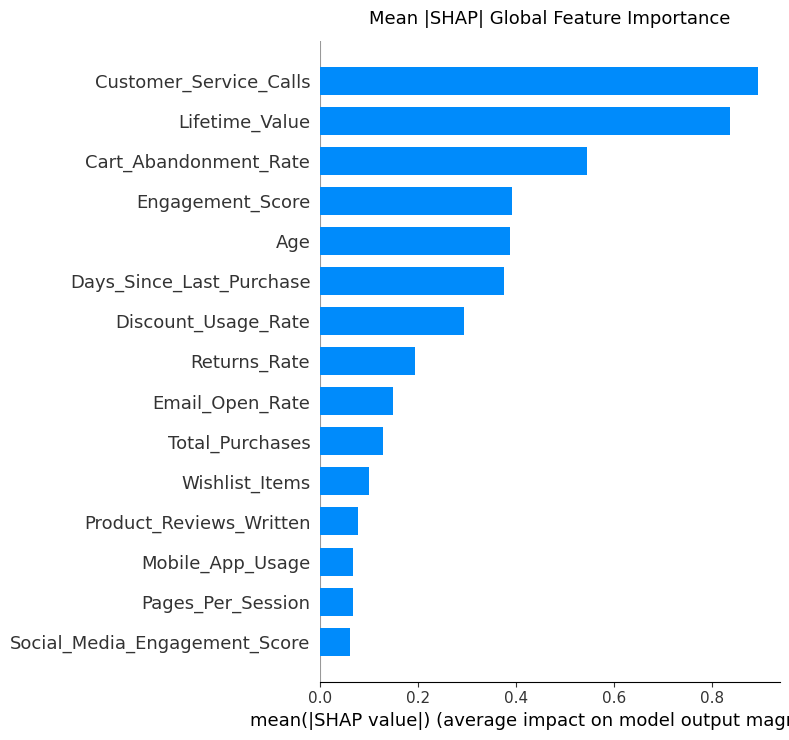

Saved: Reports/shap_summary_bar.png


In [9]:
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean |SHAP| Global Feature Importance", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../Reports/shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Reports/shap_summary_bar.png")

## Beeswarm Plot (Direction & Magnitude)

Each dot is one customer.  
- **X-axis**: SHAP value, how much that feature pushed the prediction toward churn (+) or staying (-)  
- **Colour**: actual feature value (red = high, blue = low)  

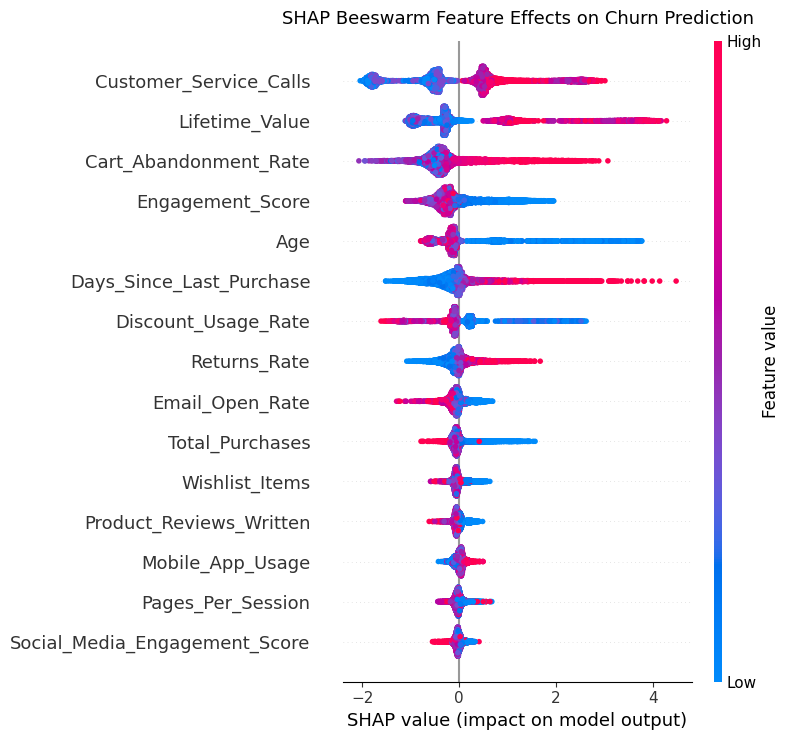

Saved: Reports/shap_beeswarm.png


In [10]:
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm Feature Effects on Churn Prediction", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../Reports/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Reports/shap_beeswarm.png")

## Dependence Plots (Top 3 Features)

Top 3 features: ['Customer_Service_Calls', 'Lifetime_Value', 'Cart_Abandonment_Rate']


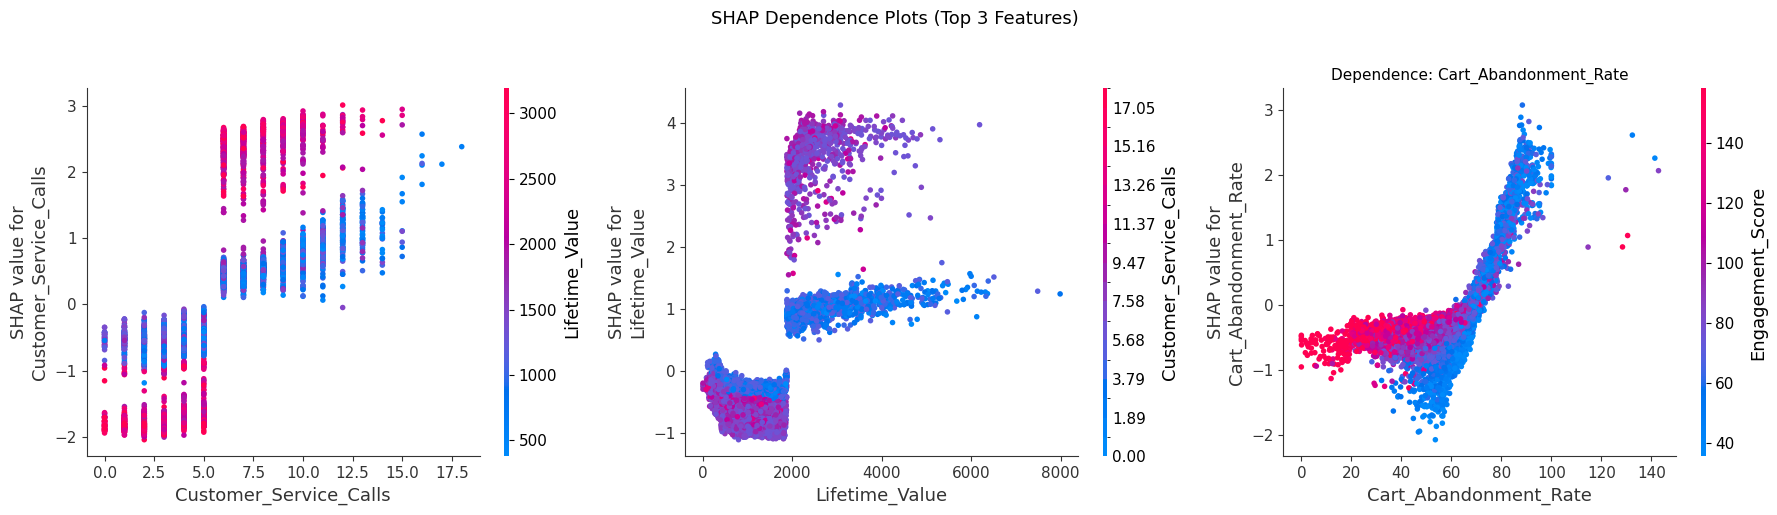

Saved: Reports/shap_dependence_top3.png


In [12]:
top_features = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)

print("Top 3 features:", top_features)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat, shap_values, X_test,
        ax=axes[i],
        show=False
    )
axes[i].set_title(f"Dependence: {feat}", fontsize=11)

plt.suptitle("SHAP Dependence Plots (Top 3 Features)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../Reports/shap_dependence_top3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Reports/shap_dependence_top3.png")

## Individual Customer Explanation (Waterfall Chart)

In [13]:
# Find a high-risk customer from the test set
y_proba_test = xgb_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argsort(y_proba_test)[-10:]  # top 10 highest churn probability

# Pick the one with highest probability
customer_idx = high_risk_idx[-1]
customer = X_test.iloc[customer_idx]
churn_prob = y_proba_test[customer_idx]

print(f"Customer index : {customer_idx}")
print(f"Churn probability : {churn_prob:.1%}")
print()
print("Customer profile (top features):")
top_feat_names = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False).head(8).index
print(customer[top_feat_names].to_string())

Customer index : 9850
Churn probability : 100.0%

Customer profile (top features):
Customer_Service_Calls         5.0
Lifetime_Value              868.84
Cart_Abandonment_Rate         69.3
Engagement_Score              47.2
Age                           18.0
Days_Since_Last_Purchase     181.0
Discount_Usage_Rate           13.1
Returns_Rate                   9.2


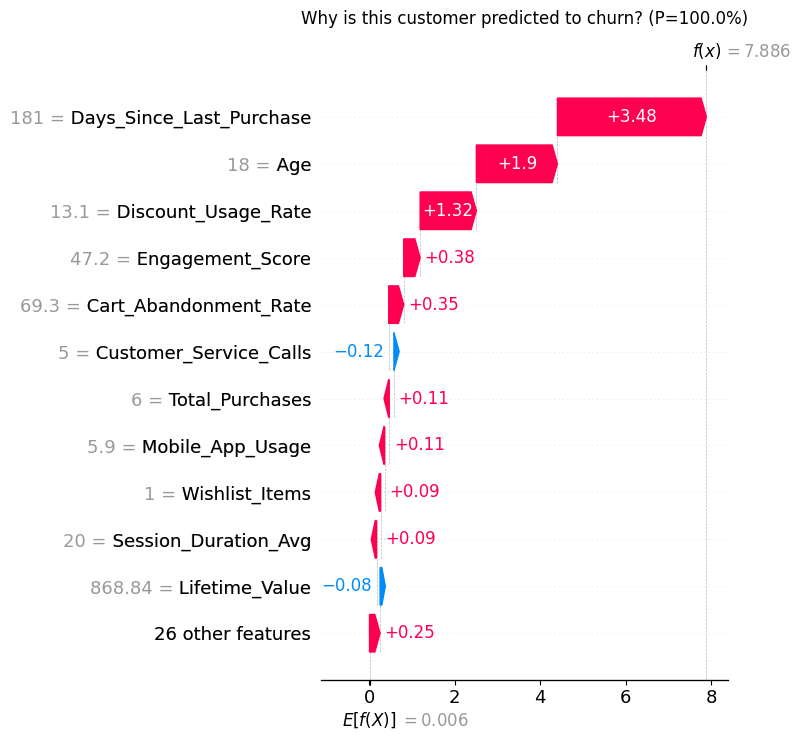

Saved: Reports/shap_waterfall_individual.png


In [14]:
# Waterfall chart for this customer
explanation = shap.Explanation(
    values=shap_values[customer_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[customer_idx].values,
    feature_names=list(X_test.columns)
)

plt.figure()
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f"Why is this customer predicted to churn? (P={churn_prob:.1%})", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("../Reports/shap_waterfall_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Reports/shap_waterfall_individual.png")

## Business Interpretation

In [16]:
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns).sort_values(ascending=False)

print("=" * 55)
print("TOP CHURN DRIVERS - BUSINESS SUMMARY")
print("=" * 55)

for feat, val in mean_shap.head(10).items():
    # Directional effect: do high values of this feature push toward churn?
    feat_vals = X_test[feat].values
    shap_feat = shap_values[:, X_test.columns.get_loc(feat)]
    corr = np.corrcoef(feat_vals, shap_feat)[0, 1]
    direction = "↑ high value = more churn" if corr > 0 else "↓ low value = more churn"
    print(f"  {feat:<35} SHAP={val:.3f}  {direction}")

print()
print("Insight: Focus retention efforts on customers with high")
print("Customer_Service_Calls and Cart_Abandonment_Rate,")
print("and low Engagement_Score and Lifetime_Value.")

TOP CHURN DRIVERS - BUSINESS SUMMARY
  Customer_Service_Calls              SHAP=0.894  ↑ high value = more churn
  Lifetime_Value                      SHAP=0.835  ↑ high value = more churn
  Cart_Abandonment_Rate               SHAP=0.545  ↑ high value = more churn
  Engagement_Score                    SHAP=0.392  ↓ low value = more churn
  Age                                 SHAP=0.387  ↓ low value = more churn
  Days_Since_Last_Purchase            SHAP=0.375  ↑ high value = more churn
  Discount_Usage_Rate                 SHAP=0.293  ↓ low value = more churn
  Returns_Rate                        SHAP=0.194  ↑ high value = more churn
  Email_Open_Rate                     SHAP=0.148  ↓ low value = more churn
  Total_Purchases                     SHAP=0.128  ↓ low value = more churn

Insight: Focus retention efforts on customers with high
Customer_Service_Calls and Cart_Abandonment_Rate,
and low Engagement_Score and Lifetime_Value.


In [17]:
feat_vals = X_test['Lifetime_Value'].values
shap_col = shap_values[:, X_test.columns.get_loc('Lifetime_Value')]

quartiles = pd.qcut(feat_vals, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

tmp = pd.DataFrame({
    'Lifetime_Value' : feat_vals,
    'SHAP_Value'     : shap_col,
    'Churned'        : y_test.values,
    'Quartile'       : quartiles
})

summary = tmp.groupby('Quartile').agg(
    Mean_LTV        = ('Lifetime_Value', 'mean'),
    Mean_SHAP       = ('SHAP_Value',     'mean'),
    Churn_Rate      = ('Churned',        'mean'),
    Customer_Count  = ('Churned',        'count')
).round(3)

print(summary)

           Mean_LTV  Mean_SHAP  Churn_Rate  Customer_Count
Quartile                                                  
Q1 (Low)    537.674     -0.427       0.420            2500
Q2         1015.169     -0.577       0.204            2500
Q3         1525.846     -0.545       0.142            2500
Q4 (High)  2673.367      1.782       0.391            2500


## What's in `Reports/` now

| File | What it shows |
|---|---|
| `shap_summary_bar.png` | Global feature ranking by mean SHAP |
| `shap_beeswarm.png` | Direction + magnitude for all customers |
| `shap_dependence_top3.png` | How top 3 features drive churn |
| `shap_waterfall_individual.png` | Single high-risk customer explanation |

These four plots, combined with the confusion matrix and ROC curve from notebook 05,  
give a complete picture of model performance *and* explainability, making model outputs **actionable**.